In [1]:
import pandas as pd
import sys

sys.path.insert(0, "..")

from src.viz import (
    plot_hist,
    boxplot_by_target,
    decile_trend_plot,
    plot_target_rate_by_category,
    plot_symptom_count_vs_rate,
    plot_risk_heatmap_2x2,
    plot_symptom_cooccurrence,
    positive_rate_by_binary
)

In [2]:
source = "../data/processed/asthma_preprocessed.csv"
reports_dir = "../reports"
fig_dir = reports_dir + "/figures"

In [3]:
df = pd.read_csv(source)
df

,Age,BMI,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,PollenExposure,DustExposure,LungFunctionFEV1,LungFunctionFVC,...,Eczema,HayFever,GastroesophagealReflux,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,0.965740,-1.582769,-1.432099,0.160113,0.971063,0.809355,-0.780866,-1.401921,-1.368934,0.920608,...,0,0,0,0,0,1,0,0,1,0
1,-0.747054,-0.623300,0.291269,0.453069,-1.076746,-1.036866,0.810184,0.560684,-0.407132,-1.564256,...,0,0,0,1,0,0,1,1,1,0
2,0.687989,-1.229074,0.581330,1.434458,-0.102976,-1.210374,-1.267434,0.162295,-0.987146,0.983019,...,0,1,0,1,1,1,0,1,1,0
3,-0.098970,1.565307,-1.256398,0.276233,-1.596880,-1.509757,0.849659,-0.355611,0.561114,-1.105641,...,0,1,0,1,0,1,1,1,0,0
4,0.873156,-1.105686,-0.154081,-0.651625,1.504976,-1.373822,-0.713717,1.146977,1.070095,-0.516586,...,0,1,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,0.039905,0.252042,-0.699950,0.376978,0.740107,-0.861740,0.760717,-0.544470,0.669296,1.093099,...,0,0,0,0,1,0,0,0,1,1
2388,-1.117388,-0.903322,0.259526,-0.218561,0.411163,0.927074,-0.980178,0.519779,-1.642920,1.356614,...,1,0,0,0,0,0,1,1,0,1
2389,0.549114,1.365905,-0.109067,1.096868,0.268175,-0.755772,-0.711873,1.574952,-1.001130,-0.302584,...,0,1,0,1,0,1,1,0,1,1
2390,0.178780,-0.527792,1.591768,0.804295,-0.174204,1.511361,0.898316,0.024327,1.082816,-1.555908,...,0,0,1,0,1,1,0,1,1,0


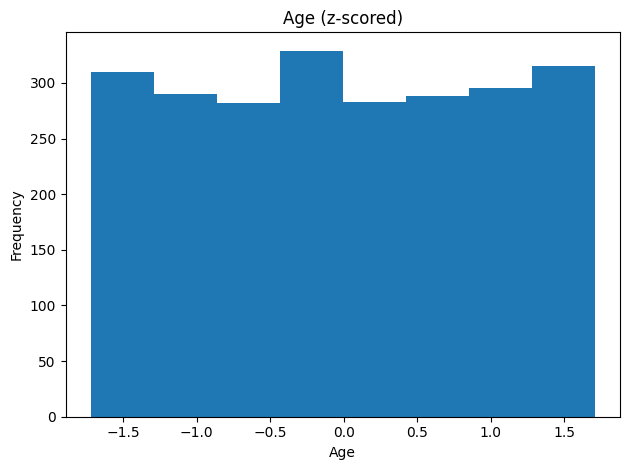

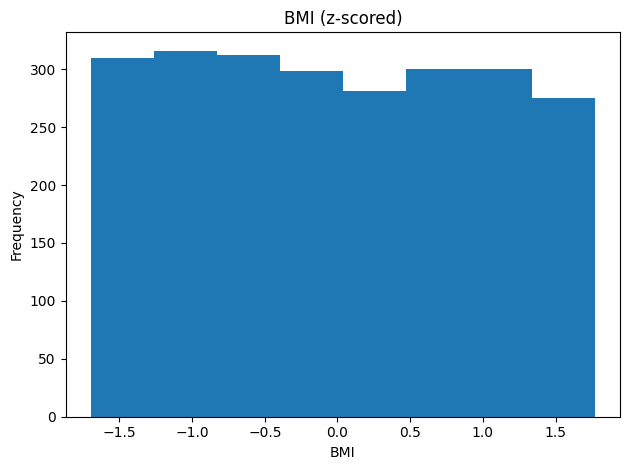

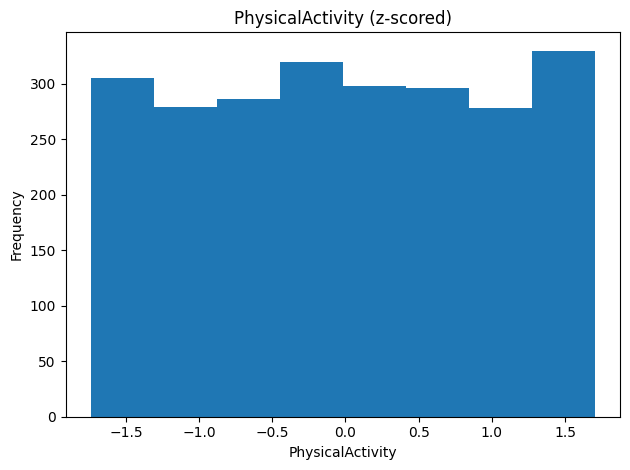

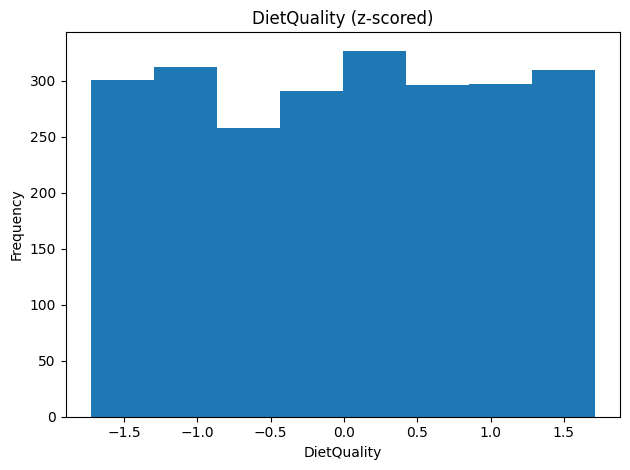

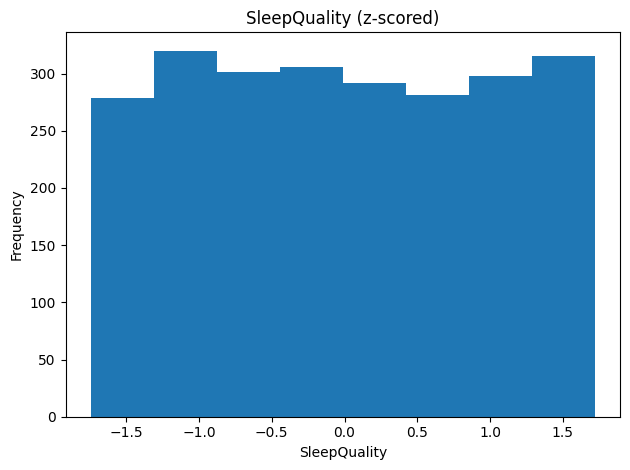

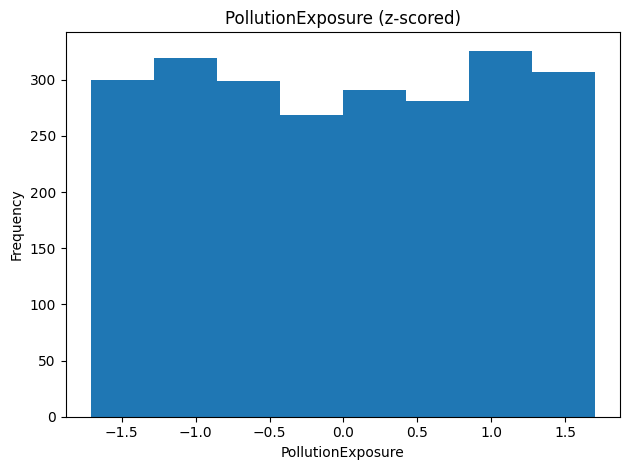

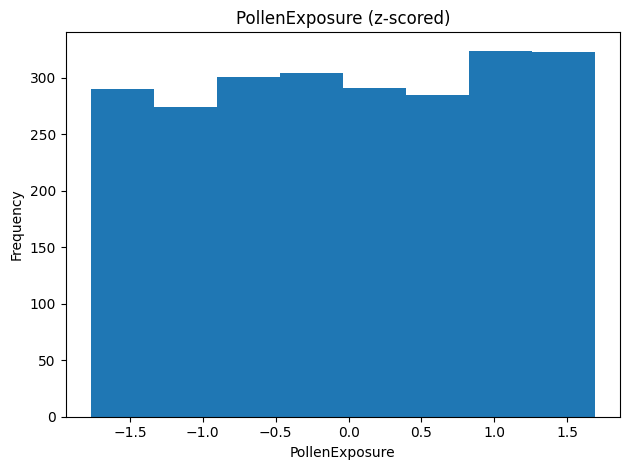

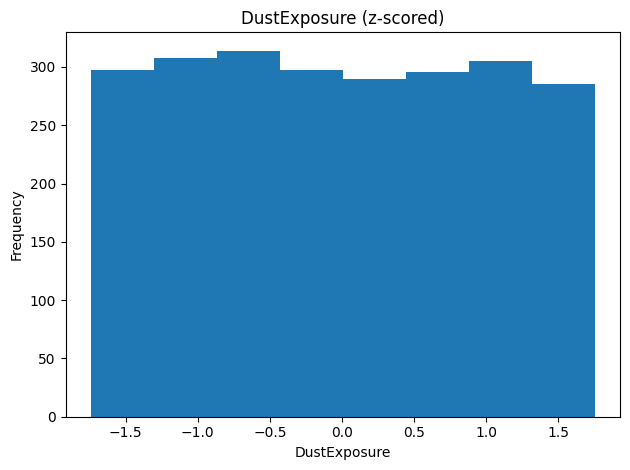

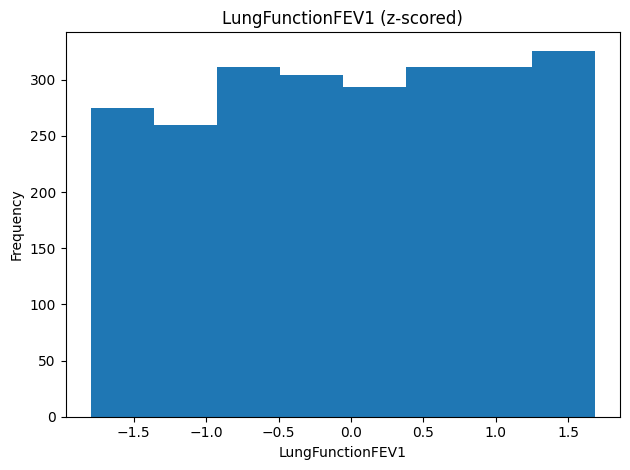

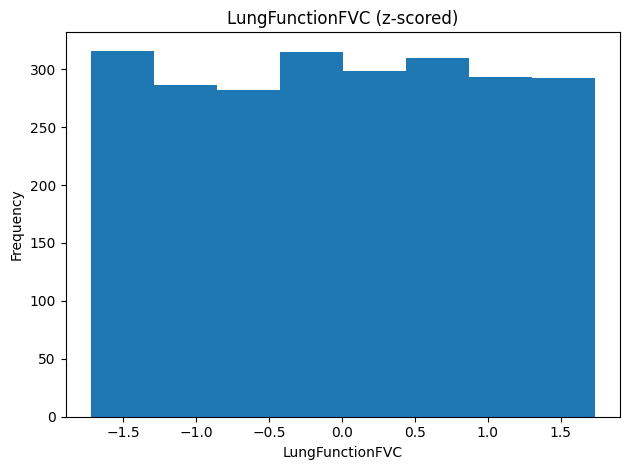

In [4]:
continuous = [
    "Age", "BMI", "PhysicalActivity", "DietQuality", "SleepQuality",
    "PollutionExposure", "PollenExposure", "DustExposure",
    "LungFunctionFEV1", "LungFunctionFVC"
]

for col in continuous:
    if col in df.columns:
        plot_hist(df, col, title=f"{col} (z-scored)", save=fig_dir + f"/02_hist_{col}.png")

All ten continuous features are nicely centered around 0 with smooth, single-peak shapes and tails that fade before +-2 SD. That means no scary outliers, no obvious skew, and no need for extra transforms. Z-scoring did its job: features are comparable in scale, and none dominates just because of units.

For Age - roughly symmetric single peak, no heavy tails. Doesn't need a transform. For BMI - slight right skew (longer tail to higher BMI). Still mild, fine to keep as-is. PhysicalActivity- noticeable right skew (many low–mid activity values, few very high). For DietQuality - near-symmetric with a soft shoulder, no strong skew. SleepQuality - mild skew (not dramatic). Clean enough to keep as-is; any effect is likely gradual, not thresholded. PollutionExposure - clear right skew (most around lower exposure, a thinner high-exposure tail). This is typical. PollenExposure - also right skew. Same story as Pollution -tail events exist but are rare; no need to clip unless they dominate a model. DustExposure - moderate right skew. LungFunctionFEV1 - slight left skew (most people near "good" function with a tail toward lower values). That's clinically plausible. LungFunctionFVC - similar left skew to FEV1. Highly related to FEV1.

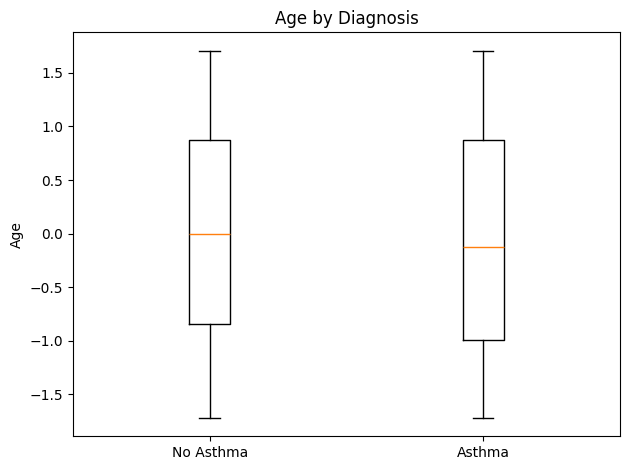

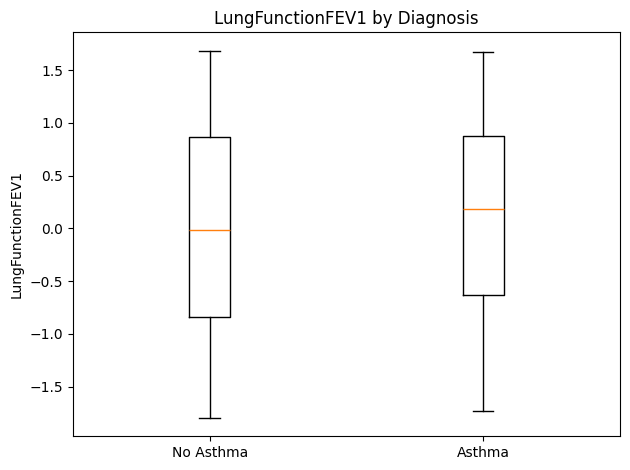

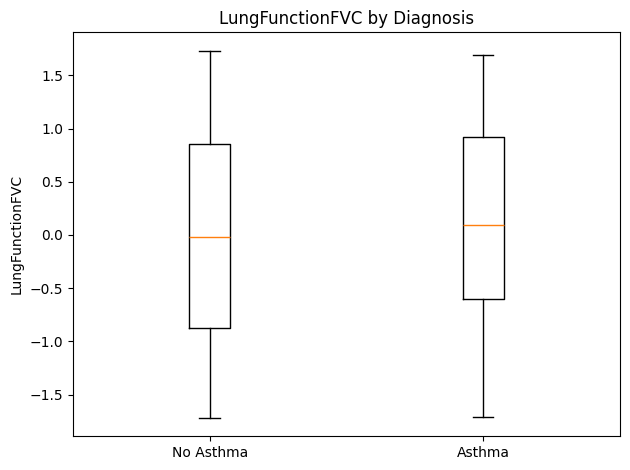

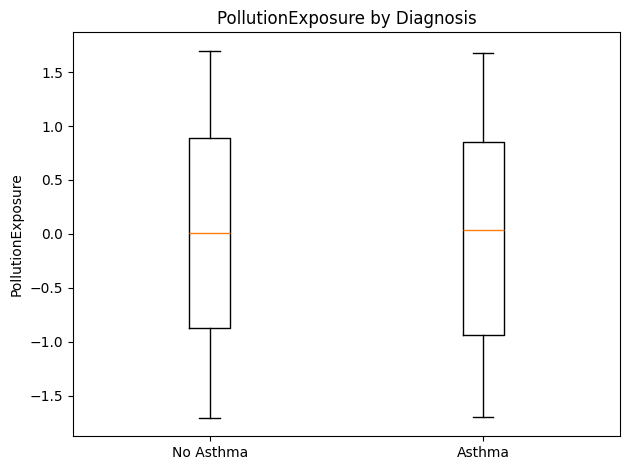

In [5]:
TARGET = "Diagnosis"
features = ["Age","LungFunctionFEV1","LungFunctionFVC","PollutionExposure"]

for col in features:
    if col in df.columns:
        boxplot_by_target(
            df, col, TARGET, labels=("No Asthma","Asthma"),
            save=fig_dir + f"/02_box_{col}_by_target.png"
        )

For Age - the asthma group's median is a bit lower than the no-asthma group, but the boxes and whiskers overlap heavily. Age provides only a tiny univariate shift. Considering LungFunctionFEV1 - in this dataset the asthma group sits slightly higher (median a touch above zero) than the no-asthma group. Still, there’s large overlap end-to-end, so FEV1 alone is a weak separator. (Since that's counter-intuitive clinically, it's worth double-checking how FEV1 was measured/normalized). Same story as FEV1 for LungFunctionFVC: the asthma group shows a small upward median shift with substantial overlap. We will treat FVC as a supporting feature, not a standalone splitter. For PollutionExposure - the two classes look nearly identical with only a tiny upward nudge for the asthma group's median. Practically, that's minimal univariate signal.

All four plots show small median shifts with big overlap. These features aren't decisive on their own; their value will come from combinations/interactions rather than expecting any one of them to cleanly separate the classes.

In [6]:
cols = ["BMI","Age","PollutionExposure","LungFunctionFEV1","LungFunctionFVC"]

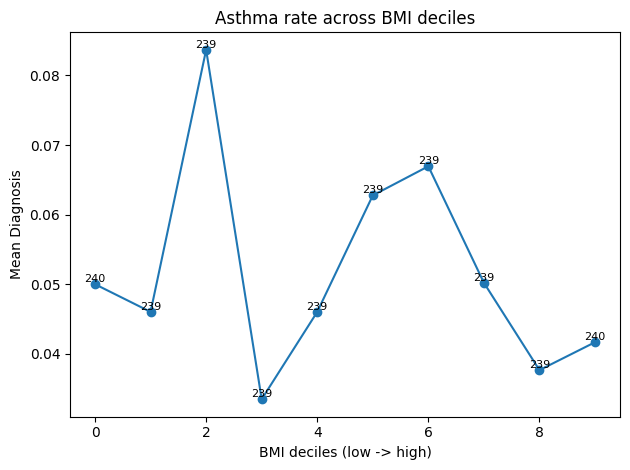

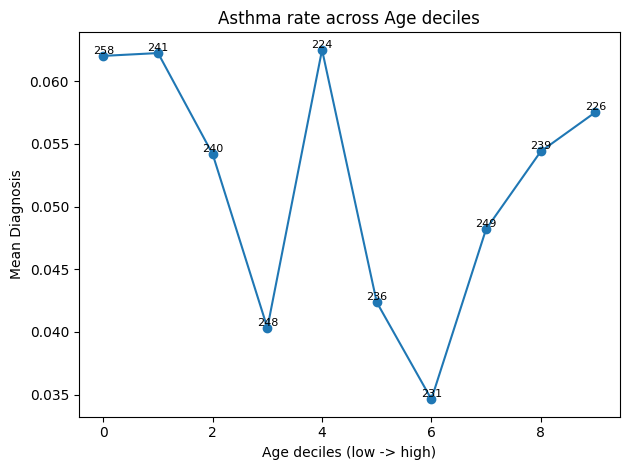

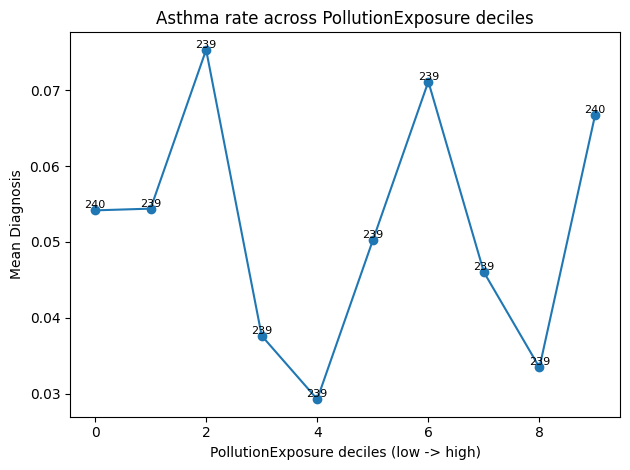

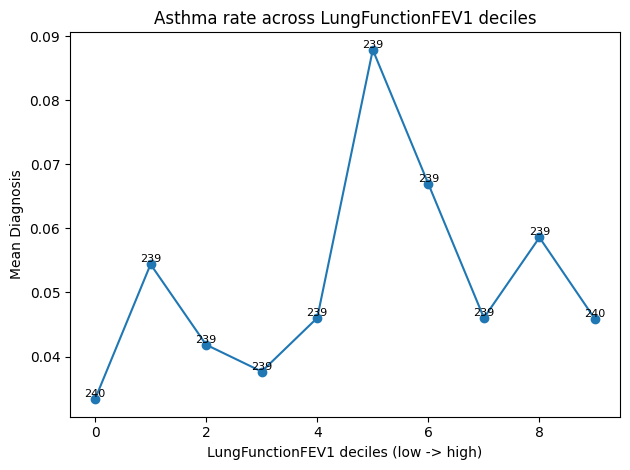

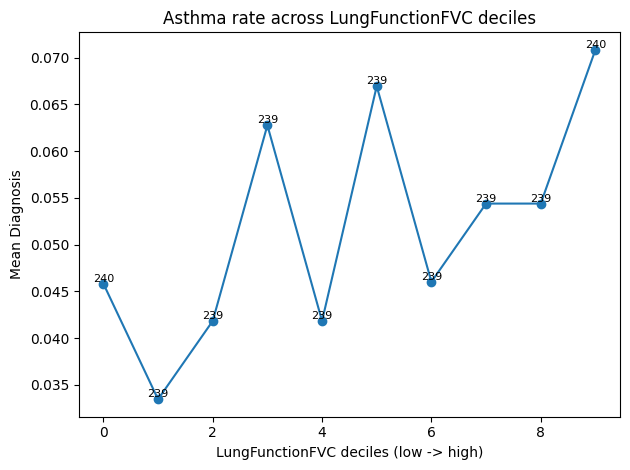

In [7]:
for c in cols:
    if c in df.columns:
        decile_trend_plot(df, c, save=fig_dir + f"/02_deciles_{c}.png")

Decile trends confirm what the histograms/boxplots hinted: weak univariate signals. Extreme deciles can be noisy (low counts) - if a point looks jumpy, it's likely small-n; merging edge bins is fine when we need stability.

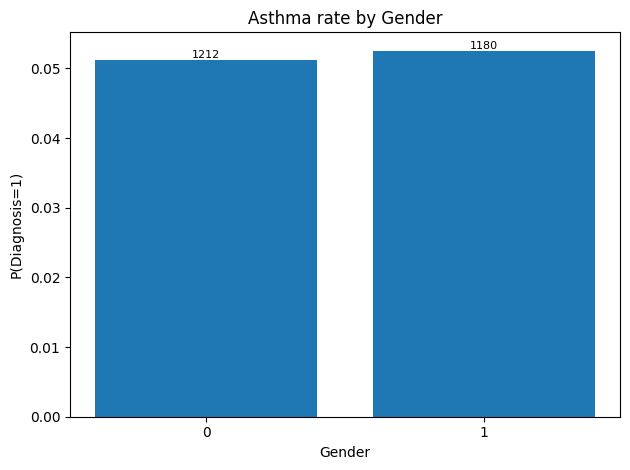

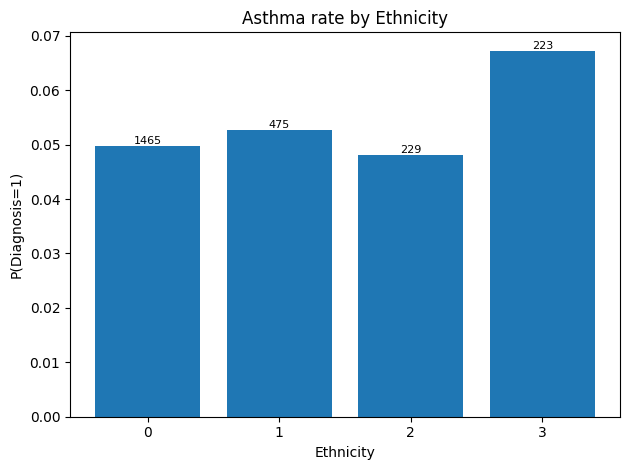

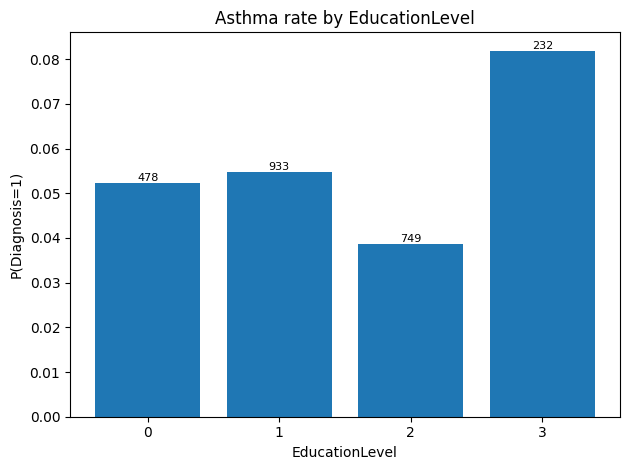

In [8]:
for c in ["Gender", "Ethnicity", "EducationLevel"]:
    if c in df.columns:
        plot_target_rate_by_category(df, c, save=fig_dir + f"/02_catrate_{c}.png")

For the gender chart - they are effectively identical => no meaningful signal from Gender on its own. Category 3 for Ethnicity shows a modest uplift, but support is smaller. Overall: weak univariate signal; we will treat any effect as mild and verify the code -> label mapping before interpreting. For education - the chart shows the clearest separation: category 3 is higher, category 2 is lower than baseline. Counts vary (cat 3 is smaller), but this looks like useful categorical signal. For modeling later, we may prefer one-hot encoding these codes so the model can capture these differences without imposing an ordinal relationship.

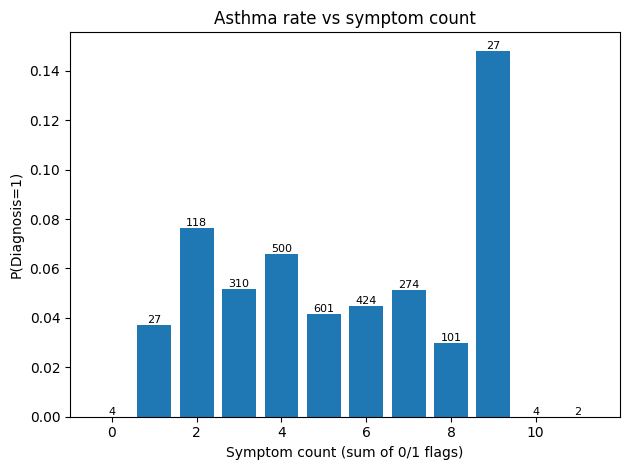

In [9]:
symptoms = [
    "Smoking", "PetAllergy", "FamilyHistoryAsthma","HistoryOfAllergies","Eczema","HayFever",
    "GastroesophagealReflux","Wheezing","ShortnessOfBreath","ChestTightness","Coughing",
    "NighttimeSymptoms","ExerciseInduced"
]

symptoms = [s for s in symptoms if s in df.columns]

plot_symptom_count_vs_rate(df, symptoms, save=fig_dir + "/02_symptomcount_vs_rate.png")

The curve does not rise smoothly. From 2–7 symptoms, the rate hovers near baseline with small wiggles - so "just more symptoms" isn't a clean predictor by itself. Low support at the edges makes the ends jumpy:

0 symptoms (n=4), 1 (n=27) - too few to trust.

9 symptoms (n=27) shows a spike, but that's also tiny n.

10 (n=4), 11 (n=2) drop to 0% - again, not reliable.

"More symptoms" alone doesn't give a monotonic risk curve here. The type of symptoms (which ones) matters more than the number. 

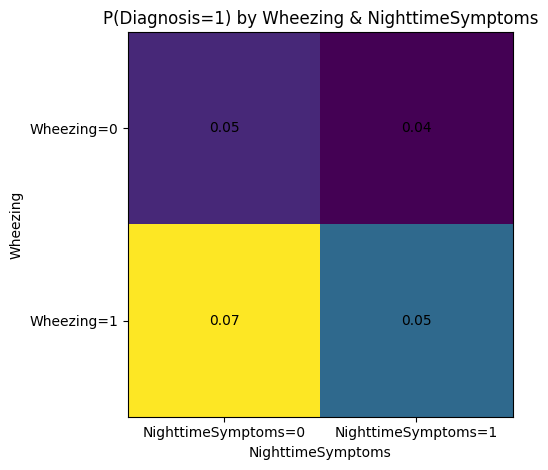

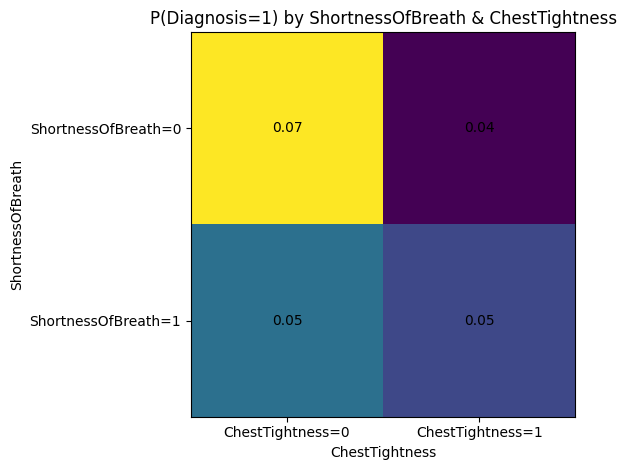

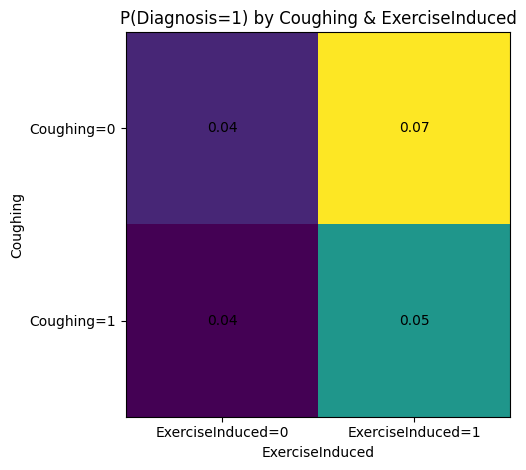

In [10]:
for a, b in [("Wheezing", "NighttimeSymptoms"), ("ShortnessOfBreath", "ChestTightness"), ("Coughing", "ExerciseInduced")]:
    if a in df.columns and b in df.columns:
        plot_risk_heatmap_2x2(df, a, b, save=fig_dir + f"/02_risk2x2_{a}_{b}.png")

Wheezing alone lifts risk; NighttimeSymptoms alone is near baseline; no synergy when both are 1 (combo is lower than Wheezing-only). For second chart, no positive interaction. Surprisingly, neither symptom flagged shows the highest rate here; both flags together don't raise risk. ExerciseInduced drives the uplift on its own for chart 3; Coughing alone is low; the combo is not super-additive (lower than ExerciseInduced-only). Across these pairs there's no strong super-additive interaction. The lift mostly comes from single flags (Wheezing, ExerciseInduced). 

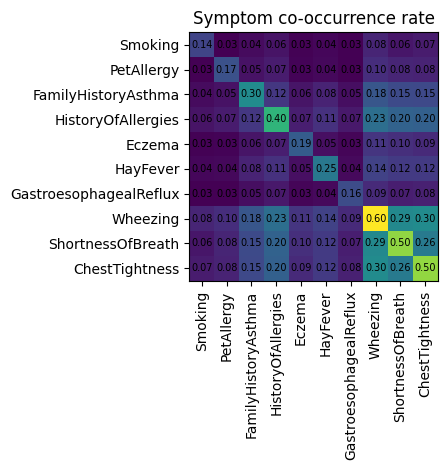

In [11]:
plot_symptom_cooccurrence(df, symptoms[:10], save=fig_dir + "/02_symptom_cooccurrence.png")

Respiratory cluster pops out. Wheezing, ShortnessOfBreath, and ChestTightness frequently appear together - they form the brightest block in the heatmap. That's our core "airflow/bronchospasm" cluster. Allergy/atopy cluster is real. HistoryOfAllergies, HayFever, PetAllergy, and (to a lesser extent) FamilyHistoryAsthma tend to co-occur. It's a softer block, but clearly above background. HistoryOfAllergies co-occurs notably with the respiratory trio (like with Wheezing and ShortnessOfBreath). Some pairs look strong simply because both are common - that's why checking lift (observed co-occurrence vs expected under independence) is important. Here, lifts are modest, so the structure is more about clusters than explosive pairwise synergies.

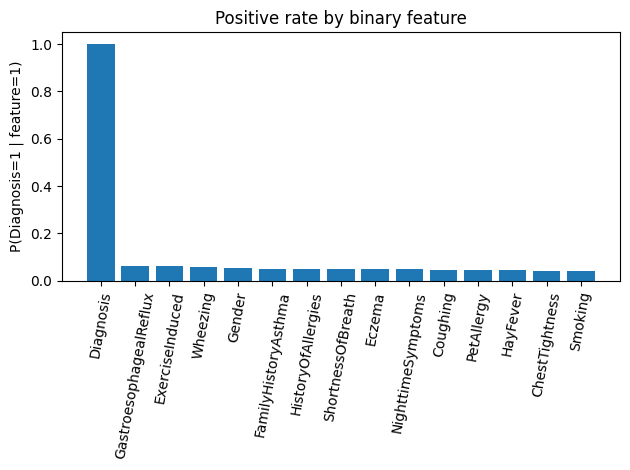

,feature,pos_rate
0,Diagnosis,1.000000
1,GastroesophagealReflux,0.063492
2,ExerciseInduced,0.061507
3,Wheezing,0.056802
4,Gender,0.052542
5,FamilyHistoryAsthma,0.051389
6,HistoryOfAllergies,0.051309
7,ShortnessOfBreath,0.048454
8,Eczema,0.047930
9,NighttimeSymptoms,0.047883


In [12]:
symptoms = [s for s in df.columns]

positive_rate_by_binary(df, symptoms, TARGET, top=len(symptoms),
                        save=fig_dir + "/02_binary_pos_rate_all.png")

Highest lifts (above baseline) include GastroesophagealReflux - 6.35%, ExerciseInduced - 6.15% and Wheezing - 5.68%. These three are our most informative single flags. Note ExerciseInduced and Wheezing also have high prevalence (cover a lot of rows), so they're broadly useful. Gender, FamilyHistoryAsthma, HistoryOfAllergies, ShortnessOfBreath, Eczema, NighttimeSymptoms and Coughing don't move risk much on their own; they'll matter more in combinations. Lower than baseline include PetAllergy, HayFever, ChestTightness and Smoking. Lower-than-baseline doesn't necessarily mean "protective" - it can reflect dataset coding, co-management, or confounding.

That's the end! Data is clean, continuous features are well-behaved, z-scored, no heavy tails -> no extra transforms needed. Categorical codes - EducationLevel carries the clearest separation; Gender is neutral; Ethnicity has a modest high-risk category with smaller support. Binary lifts: GERD, ExerciseInduced, Wheezing provide the top (but modest) uplift; many others hover near baseline. The structure is characterised by a clear respiratory cluster (Wheezing, SOB, ChestTightness) and atopy cluster (HistoryOfAllergies, HayFever, PetAllergy) with co-occurrence; little evidence of strong pairwise synergy.